<a href="https://colab.research.google.com/github/gayakarapetyan/PythonCourseH2/blob/main/Session2/Session2_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 2 Part 2 — Wetterdienst, Correlation & Linear Regression
### *Statistics & Machine Learning *

---



In [ ]:
!pip install wetterdienst --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print('Ready!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.1/244.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 104.3 MB/s eta 0:00:00
✅  Ready!


---
## Part 1 — Introducing Wetterdienst

`wetterdienst` gives you direct access to data from the
**Deutscher Wetterdienst (DWD)** — Germany's national weather service.

Instead of downloading files manually, a few lines of Python
give you clean data directly in a pandas DataFrame.


> **Important note:** wetterdienst internally uses the `polars` library.
> We always call `.to_pandas()` right after fetching
> so everything works with normal pandas syntax.

### 1.1 — What parameters are available?

In [ ]:
# Discover all available daily parameters
from wetterdienst.provider.dwd.observation import DwdObservationRequest

metadata = DwdObservationRequest.discover(resolutions='daily')

print('Available daily datasets and their parameters:')
print()
for dataset, params in metadata['daily'].items():
    print(f'Dataset: {dataset}')
    for p in params:
        print(f'      {p["name"]:<40} [{p["unit"]}]')
    print()

Available daily datasets and their parameters:

Dataset: climate_summary
      wind_gust_max                            [meter_per_second]
      wind_speed                               [meter_per_second]
      precipitation_height                     [millimeter]
      precipitation_form                       [dimensionless]
      sunshine_duration                        [hour]
      snow_depth                               [centimeter]
      cloud_cover_total                        [one_eighth]
      pressure_vapor                           [hectopascal]
      pressure_air_site                        [hectopascal]
      temperature_air_mean_2m                  [degree_celsius]
      humidity                                 [percent]
      temperature_air_max_2m                   [degree_celsius]
      temperature_air_min_2m                   [degree_celsius]
      temperature_air_min_0_05m                [degree_celsius]

Dataset: precipitation_more
      precipitation_height        

### 1.2 — The `climate_summary` dataset

The most useful dataset is **`climate_summary`** — all main variables in one call:

| Variable | Description | Unit |
|---|---|---|
| `temperature_air_mean_2m` | Mean daily temperature | °C |
| `temperature_air_max_2m` | Maximum daily temperature | °C |
| `temperature_air_min_2m` | Minimum daily temperature | °C |
| `precipitation_height` | Daily precipitation | mm |
| `sunshine_duration` | Daily sunshine duration | hours |
| `pressure_vapor` | Vapor pressure (humidity proxy) | hPa |
| `wind_speed` | Mean daily wind speed | m/s |
| `wind_gust_max` | Maximum wind gust | m/s |
| `cloud_cover_total` | Cloud cover | eighths (0–8) |
| `snow_depth` | Snow depth | cm |


### 1.3 — Search for stations

In [ ]:
# Create a request and get all available stations
# .to_pandas() converts from polars to pandas — we do this once here

from wetterdienst import Settings

settings = Settings(ts_shape='wide', ts_humanize=True, ts_convert_units=True)

request = DwdObservationRequest(
    parameters=[('daily', 'climate_summary')],
    start_date='2000-01-01',
    end_date='2023-12-31',
    settings=settings
)

# Fetch all stations and convert to pandas immediately
all_stations = request.all().df.to_pandas()

print(f'Total stations with climate_summary data: {len(all_stations)}')
print()
print('Column names:', all_stations.columns.tolist())
print()
print(all_stations.head(3))


Total stations with climate_summary data: 1281

Column names: ['resolution', 'dataset', 'station_id', 'start_date', 'end_date', 'latitude', 'longitude', 'height', 'name', 'state']

  resolution          dataset station_id                start_date  \
0      daily  climate_summary      00001 1937-01-01 00:00:00+00:00   
1      daily  climate_summary      00003 1891-01-01 00:00:00+00:00   
2      daily  climate_summary      00011 1980-09-01 00:00:00+00:00   

                   end_date  latitude  longitude  height  \
0 1986-06-30 00:00:00+00:00   47.8413     8.8493   478.0   
1 2011-03-31 00:00:00+00:00   50.7827     6.0941   202.0   
2 2026-05-20 00:00:00+00:00   47.9736     8.5205   680.0   

                          name                state  
0                         Aach    Baden-Württemberg  
1                       Aachen  Nordrhein-Westfalen  
2  Donaueschingen (Landeplatz)    Baden-Württemberg  


In [ ]:
# Filter to Saxony-Anhalt
sa_stations = all_stations[
    all_stations['state'].str.contains('Sachsen-Anhalt', na=False)
].copy()

print(f'Stations in Saxony-Anhalt: {len(sa_stations)}')
print()
print(sa_stations[['station_id','name','latitude','longitude','height']]
      .to_string(index=False))


Stations in Saxony-Anhalt: 57

station_id                       name  latitude  longitude  height
     00181                   Arendsee   52.8761    11.5042    30.0
     00184                   Arneburg   52.6769    12.0077    55.0
     00207               Aschersleben   51.7498    11.4667   105.0
     00351  Oberharz am Brocken-Sorge   51.6926    10.6978   502.0
     00445      Bernburg/Saale (Nord)   51.8218    11.7110    85.0
     00524                 Bitterfeld   51.6333    12.3167    80.0
     00722                    Brocken   51.7986    10.6183  1135.0
     00948                     Dessau   51.8512    12.2515    60.0
     01052            Möckern-Drewitz   52.2174    12.1641    80.0
     01074            Dürrenberg, Bad   51.3043    12.0810   103.0
     01182            Eisleben-Helfta   51.5029    11.5705   146.0
     01488            Friedrichsbrunn   51.6884    11.0394   523.0
     01544                 Gardelegen   52.5129    11.3942    47.0
     01605                    G

In [1]:
# Check which of our Selke stations have full climate data
# These are the stations we worked with in Session 2

selke_names = ['Harzgerode', 'Quedlinburg', 'Aschersleben', 'Oberharz',
               'Staßfurt', 'Seeland', 'Winningen']

print('Selke-area stations with full climate_summary data:')
print()
for name in selke_names:
    found = all_stations[
        all_stations['name'].str.contains(name, case=False, na=False)
    ]
    if len(found) > 0:
        for _, row in found.iterrows():
            print(f"{row['name']:<40} "
                  f"ID: {row['station_id']}  "
                  f"({row['latitude']:.3f}, {row['longitude']:.3f})  "
                  f"elev: {row['height']:.0f}m")
    else:
        print(f'{name} — no full climate data available')


Selke-area stations with full climate_summary data:



NameError: name 'all_stations' is not defined

### 1.4 — Find nearest stations to a location

In [ ]:
# Find stations within 50 km of Magdeburg
# Useful when you don't know station names

MAGDEBURG_LAT = 52.1316
MAGDEBURG_LON = 11.6392

nearest = request.filter_by_distance(
    latlon=(MAGDEBURG_LAT, MAGDEBURG_LON),
    distance=50,
    unit='km'
).df.to_pandas()   # ← always convert to pandas

print('Stations within 50 km of Magdeburg:')
print()
print(nearest[['station_id','name','latitude','longitude','height','distance']]
      .sort_values('distance')
      .to_string(index=False))


Stations within 50 km of Magdeburg:

station_id                   name  latitude  longitude  height  distance
     03126              Magdeburg   52.1029    11.5827    79.0    5.0067
     05158              Ummendorf   52.1601    11.1759   159.0   31.7717
     02760                Krüssau   52.2880    12.0707    45.0   34.1594
     00445  Bernburg/Saale (Nord)   51.8218    11.7110    85.0   34.7975
     05761                 Zerbst   51.9642    12.0996    69.0   36.5753
     01052        Möckern-Drewitz   52.2174    12.1641    80.0   37.0432
     04593            Schwanebeck   51.9639    11.1208   117.0   40.0560
     05267           Wackersleben   52.0722    11.0222    86.0   42.6570
     02120              Helmstedt   52.2164    11.0219   140.0   43.1380
     00207           Aschersleben   51.7498    11.4667   105.0   44.0702
     06273                 Demker   52.5075    11.8551    36.0   44.2992
     01605                Genthin   52.3875    12.1602    35.0   45.4648
     01544    

### 1.5 — Fetch data for one station

In [ ]:
# Fetch climate_summary for Harzgerode
# We know this station well from Part 1!

request_hg = DwdObservationRequest(
    parameters=[('daily', 'climate_summary')],
    start_date='2000-01-01',
    end_date='2023-12-31',
    settings=settings
).filter_by_name('Harzgerode')

# Fetch and convert to pandas immediately
df_raw = request_hg.values.all().df.to_pandas()

print('Raw data shape:', df_raw.shape)
print()
print('Columns:', df_raw.columns.tolist())
print()
print(df_raw.head(6))


Raw data shape: (8764, 32)

Columns: ['station_id', 'resolution', 'dataset', 'date', 'wind_gust_max', 'qn_wind_gust_max', 'wind_speed', 'qn_wind_speed', 'precipitation_height', 'qn_precipitation_height', 'precipitation_form', 'qn_precipitation_form', 'sunshine_duration', 'qn_sunshine_duration', 'snow_depth', 'qn_snow_depth', 'cloud_cover_total', 'qn_cloud_cover_total', 'pressure_vapor', 'qn_pressure_vapor', 'pressure_air_site', 'qn_pressure_air_site', 'temperature_air_mean_2m', 'qn_temperature_air_mean_2m', 'humidity', 'qn_humidity', 'temperature_air_max_2m', 'qn_temperature_air_max_2m', 'temperature_air_min_2m', 'qn_temperature_air_min_2m', 'temperature_air_min_0_05m', 'qn_temperature_air_min_0_05m']

  station_id resolution          dataset                      date  \
0      02044      daily  climate_summary 2000-01-01 00:00:00+00:00   
1      02044      daily  climate_summary 2000-01-02 00:00:00+00:00   
2      02044      daily  climate_summary 2000-01-03 00:00:00+00:00   
3      0

### 1.6 — Clean and understand the data

In [ ]:
# Clean the raw dataframe step by step

df = df_raw.copy()

# Step 1 — parse date and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Step 2 — keep only weather columns
drop_cols = ['station_id', 'dataset', 'quality']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Step 3 — replace sentinel values with NaN
df = df.replace(-999, np.nan)
df = df.replace(-999.0, np.nan)

print('Cleaned dataframe:')
print(f'  Shape     : {df.shape}')
print(f'  Date range: {df.index.min().date()} → {df.index.max().date()}')
print()
print('Variables and data completeness:')
print()
for col in df.columns:
    n_valid = df[col].notna().sum()
    pct     = n_valid / len(df) * 100
    print(f'  {col:<40} {n_valid:>6,} days  ({pct:.0f}%)')


Cleaned dataframe:
  Shape     : (8764, 29)
  Date range: 2000-01-01 → 2023-12-31

Variables and data completeness:

  resolution                                8,764 days  (100%)
  wind_gust_max                             8,648 days  (99%)
  qn_wind_gust_max                          8,648 days  (99%)
  wind_speed                                8,631 days  (98%)
  qn_wind_speed                             8,631 days  (98%)
  precipitation_height                      8,741 days  (100%)
  qn_precipitation_height                   8,741 days  (100%)
  precipitation_form                        8,741 days  (100%)
  qn_precipitation_form                     8,741 days  (100%)
  sunshine_duration                         8,720 days  (99%)
  qn_sunshine_duration                      8,720 days  (99%)
  snow_depth                                4,090 days  (47%)
  qn_snow_depth                             4,090 days  (47%)
  cloud_cover_total                         5,785 days  (66%)
  qn_cloud

In [ ]:
# Basic statistics for every variable
print('Summary statistics:')
print(df.describe().round(2).T)

Summary statistics:

                               count      mean       std     min      25%  \
wind_gust_max                 8648.0     10.76      3.96    1.50     7.88   
qn_wind_gust_max              8648.0     10.00      0.00   10.00    10.00   
wind_speed                    8631.0      3.64      1.58    0.30     2.50   
qn_wind_speed                 8631.0     10.00      0.00   10.00    10.00   
precipitation_height          8741.0      1.60      3.94    0.00     0.00   
qn_precipitation_height       8741.0      7.40      2.77    1.00     3.00   
precipitation_form            8741.0      3.37      2.52    0.00     0.00   
qn_precipitation_form         8741.0      7.40      2.77    1.00     3.00   
sunshine_duration             8720.0  16571.93  15340.39    0.00  1800.00   
qn_sunshine_duration          8720.0      7.39      2.78    1.00     3.00   
snow_depth                    4090.0      2.07      7.12    0.00     0.00   
qn_snow_depth                 4090.0      7.97      2.3

---
## Part 2 — Fetching Multiple Stations

Wetterdienst can fetch data for multiple stations in one call.
We use Harzgerode (mountain), Quedlinburg (foothills), Magdeburg (plain)
— a nice elevation gradient to compare.


In [ ]:
# Fetch 3 stations at once
df_multi = pd.concat([
    DwdObservationRequest(
        parameters=[('daily', 'climate_summary')],
        start_date='2000-01-01',
        end_date='2023-12-31',
        settings=settings
    ).filter_by_name(name).values.all().df.to_pandas().assign(name=name)
    for name in ['Harzgerode', 'Quedlinburg', 'Magdeburg']
])

df_multi['date'] = pd.to_datetime(df_multi['date'])
print('Stations fetched:')
print(df_multi['name'].unique())
print('Shape:', df_multi.shape)

Stations fetched:
['Harzgerode' 'Quedlinburg' 'Magdeburg']
Shape: (23770, 33)


In [ ]:
#change the format: one column per station
temp_wide = df_multi.pivot_table(
    index='date',
    columns='name',
    values='temperature_air_mean_2m'
)

print('Annual mean temperature per station:')
means = temp_wide.mean().sort_values()
for name, t in means.items():
    print(f'  {name:<30} {t:.2f} °C')
print()
print('Colder = higher elevation?')
print('Temperature drops ~0.65°C per 100m — does your data match?')


Annual mean temperature per station:
  Harzgerode                     8.19 °C
  Magdeburg                      10.49 °C
  Quedlinburg                    10.54 °C

Colder = higher elevation?
Temperature drops ~0.65°C per 100m — does your data match?


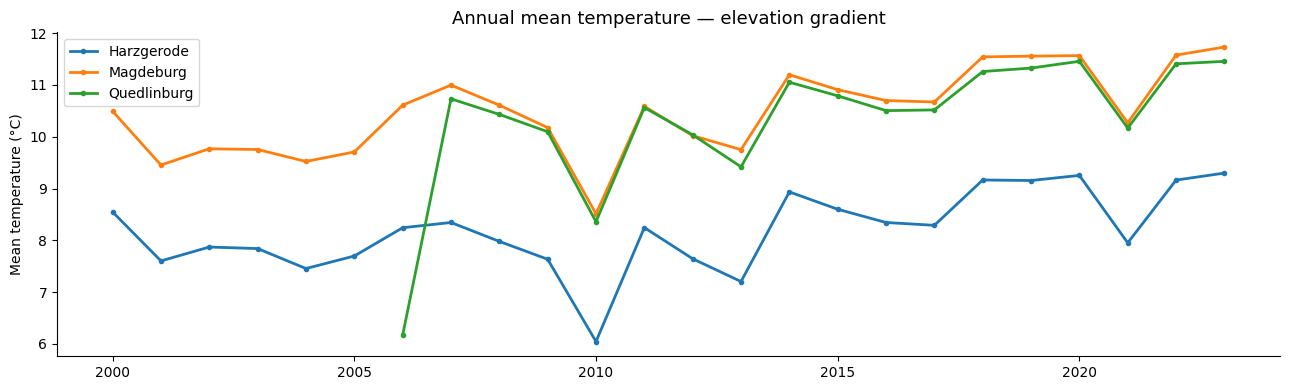

In [ ]:
# Plot annual mean temperature for all 3 stations
annual_temp = temp_wide.resample('YE').mean()

fig, ax = plt.subplots(figsize=(13, 4))
for col in annual_temp.columns:
    ax.plot(annual_temp.index.year, annual_temp[col],
            linewidth=2, label=col, marker='o', markersize=3)

ax.set_title('Annual mean temperature — elevation gradient', fontsize=13)
ax.set_ylabel('Mean temperature (°C)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


---
## Part 3 — Exploring All Variables

Before any correlation analysis, we look at each variable carefully.
We use Harzgerode (`df` from Part 1).


In [ ]:
#how to select specific date
'''df[df.index.year == 2015]
df[df.index.month == 7]          # all Julys across all years
df[(df.index.year == 2015) & (df.index.month == 7)]
df[df.index.date == pd.Timestamp('2015-07-15').date()]
# Select specific dates
df['2015-06-01':'2015-08-31']
# boolean mask
df[(df.index >= '2015-06-01') & (df.index <= '2015-08-31')]
#.loc with strings
df.loc['2015-06-01':'2015-08-31']
df['2015-07']
df.last('30D')
df[df.index.dayofweek == 0] '''

"df[df.index.year == 2015]\ndf[df.index.month == 7]          # all Julys across all years\ndf[(df.index.year == 2015) & (df.index.month == 7)]\ndf[df.index.date == pd.Timestamp('2015-07-15').date()]\n# Select specific dates\ndf['2015-06-01':'2015-08-31']\n# boolean mask\ndf[(df.index >= '2015-06-01') & (df.index <= '2015-08-31')]\n#.loc with strings\ndf.loc['2015-06-01':'2015-08-31']\ndf['2015-07'] \ndf.last('30D') \ndf[df.index.dayofweek == 0] "

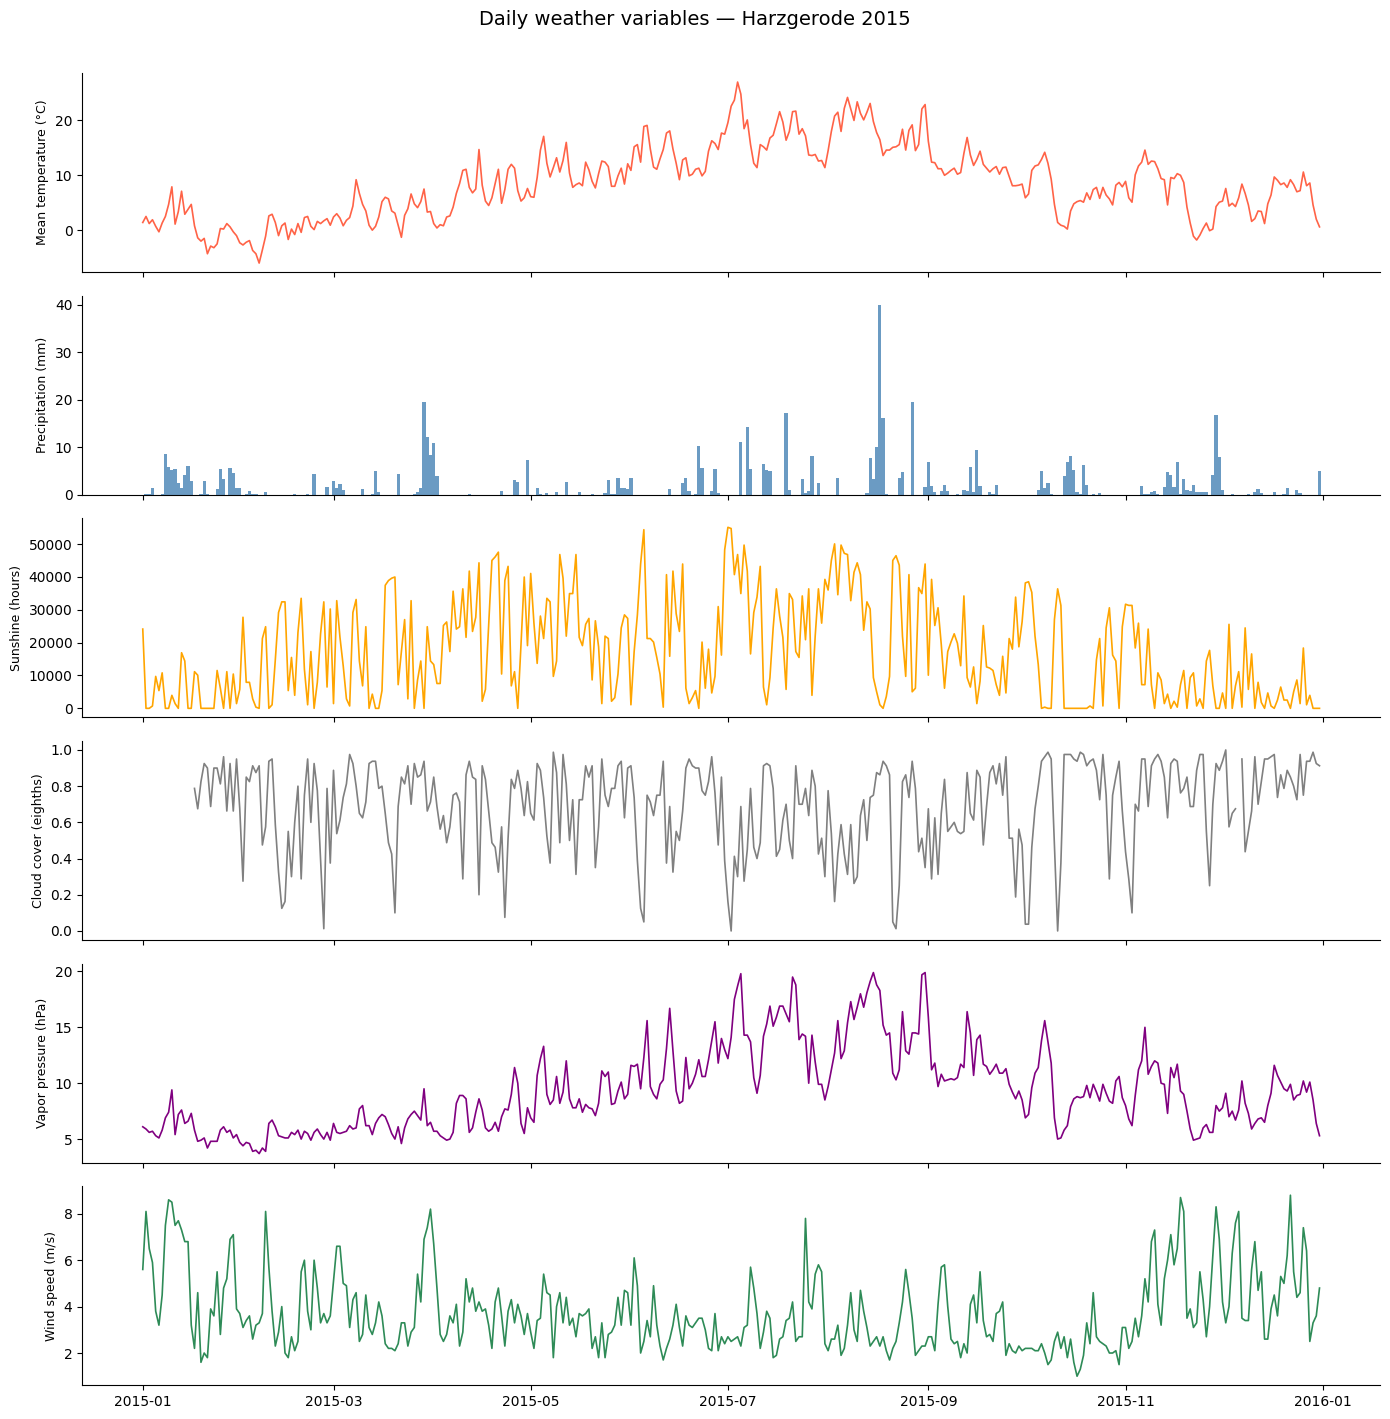

In [ ]:
# Plot all variables for one year

plot_vars = {
    'temperature_air_mean_2m': ('Mean temperature (°C)', 'tomato'),
    'precipitation_height':     ('Precipitation (mm)',    'steelblue'),
    'sunshine_duration':        ('Sunshine (hours)',      'orange'),
    'cloud_cover_total':        ('Cloud cover (eighths)', 'grey'),
    'pressure_vapor':           ('Vapor pressure (hPa)',  'purple'),
    'wind_speed':               ('Wind speed (m/s)',      'seagreen'),
}

# Filter to variables that actually exist in our dataframe
plot_vars = {k: v for k, v in plot_vars.items() if k in df.columns}

df_year = df[df.index.year == 2015].copy()

fig, axes = plt.subplots(len(plot_vars), 1, figsize=(14, 14), sharex=True)
fig.suptitle('Daily weather variables — Harzgerode 2015', fontsize=14, y=1.01)

for ax, (var, (label, color)) in zip(axes, plot_vars.items()):
    if var == 'precipitation_height':
        ax.bar(df_year.index, df_year[var].fillna(0),
               color=color, width=1, alpha=0.8)
    else:
        ax.plot(df_year.index, df_year[var], color=color, linewidth=1.2)
    ax.set_ylabel(label, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


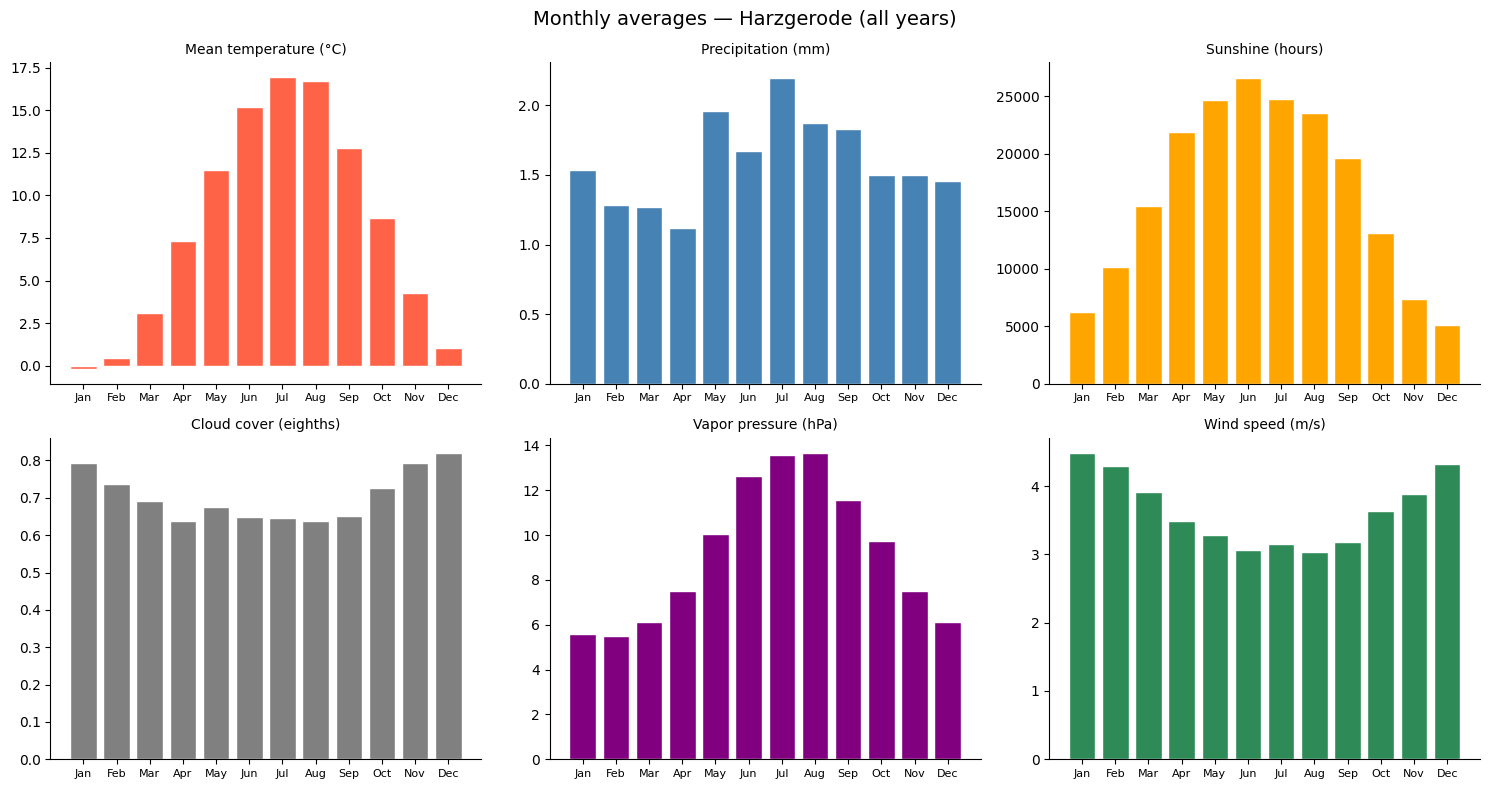

In [ ]:
# Monthly averages of all variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Monthly averages — Harzgerode (all years)', fontsize=14)

for ax, (var, (label, color)) in zip(axes.flat, plot_vars.items()):
    monthly = df[var].groupby(df.index.month).mean()
    ax.bar(range(1, 13), monthly.values, color=color, edgecolor='white')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

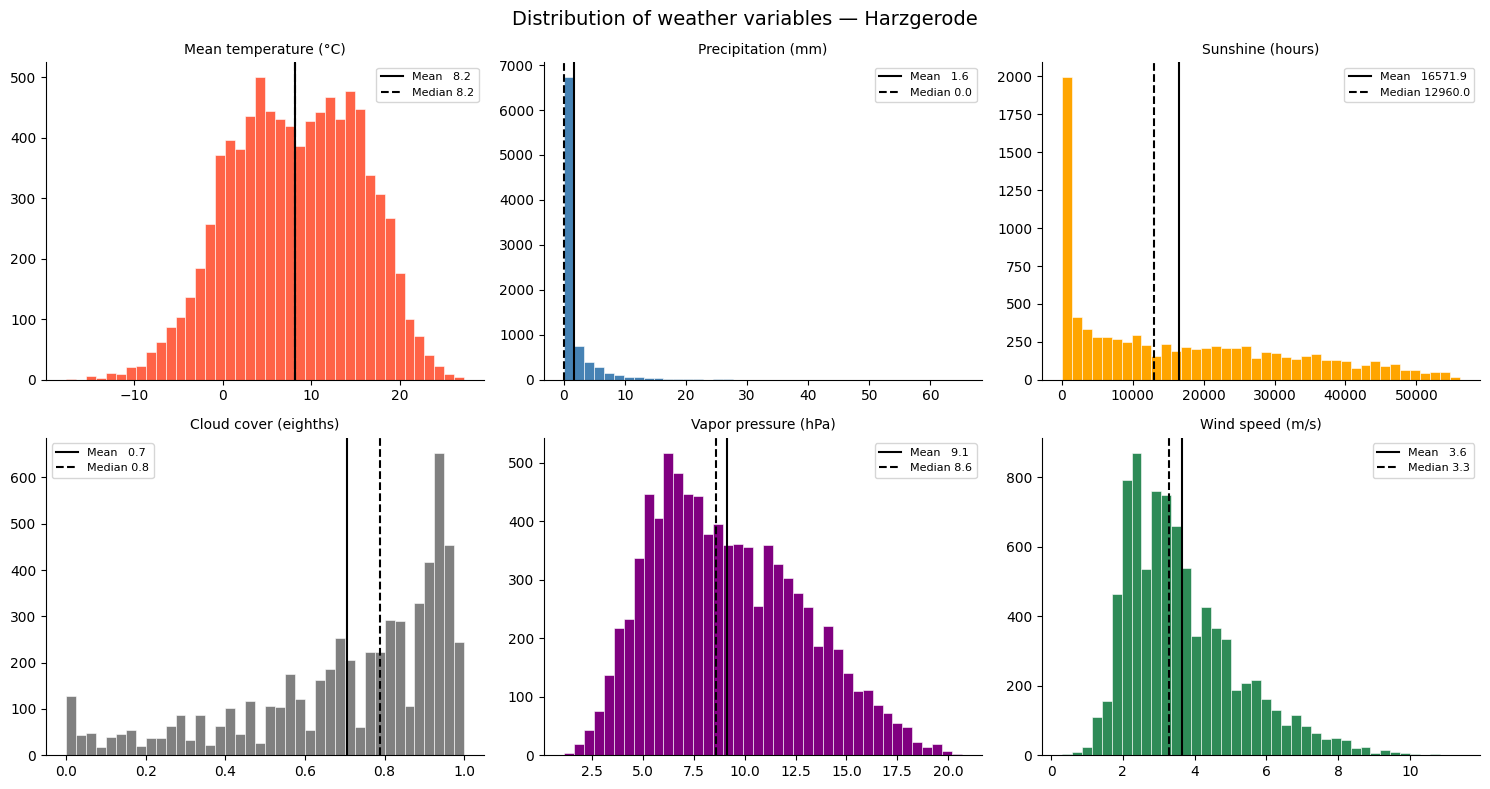

In [ ]:
# Histograms with mean and median
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of weather variables — Harzgerode', fontsize=14)

for ax, (var, (label, color)) in zip(axes.flat, plot_vars.items()):
    data = df[var].dropna()
    ax.hist(data, bins=40, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(),   color='black', linewidth=1.5,
               linestyle='-',  label=f'Mean   {data.mean():.1f}')
    ax.axvline(data.median(), color='black', linewidth=1.5,
               linestyle='--', label=f'Median {data.median():.1f}')
    ax.set_title(label, fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# Task: explore any station you want, make plots and print stat descriptions



---
## Part 4 — Correlation

**Pearson correlation coefficient r:**

| Value | Meaning |
|---|---|
| r = +1 | Perfect positive relationship |
| r =  0 | No linear relationship |
| r = -1 | Perfect negative relationship |

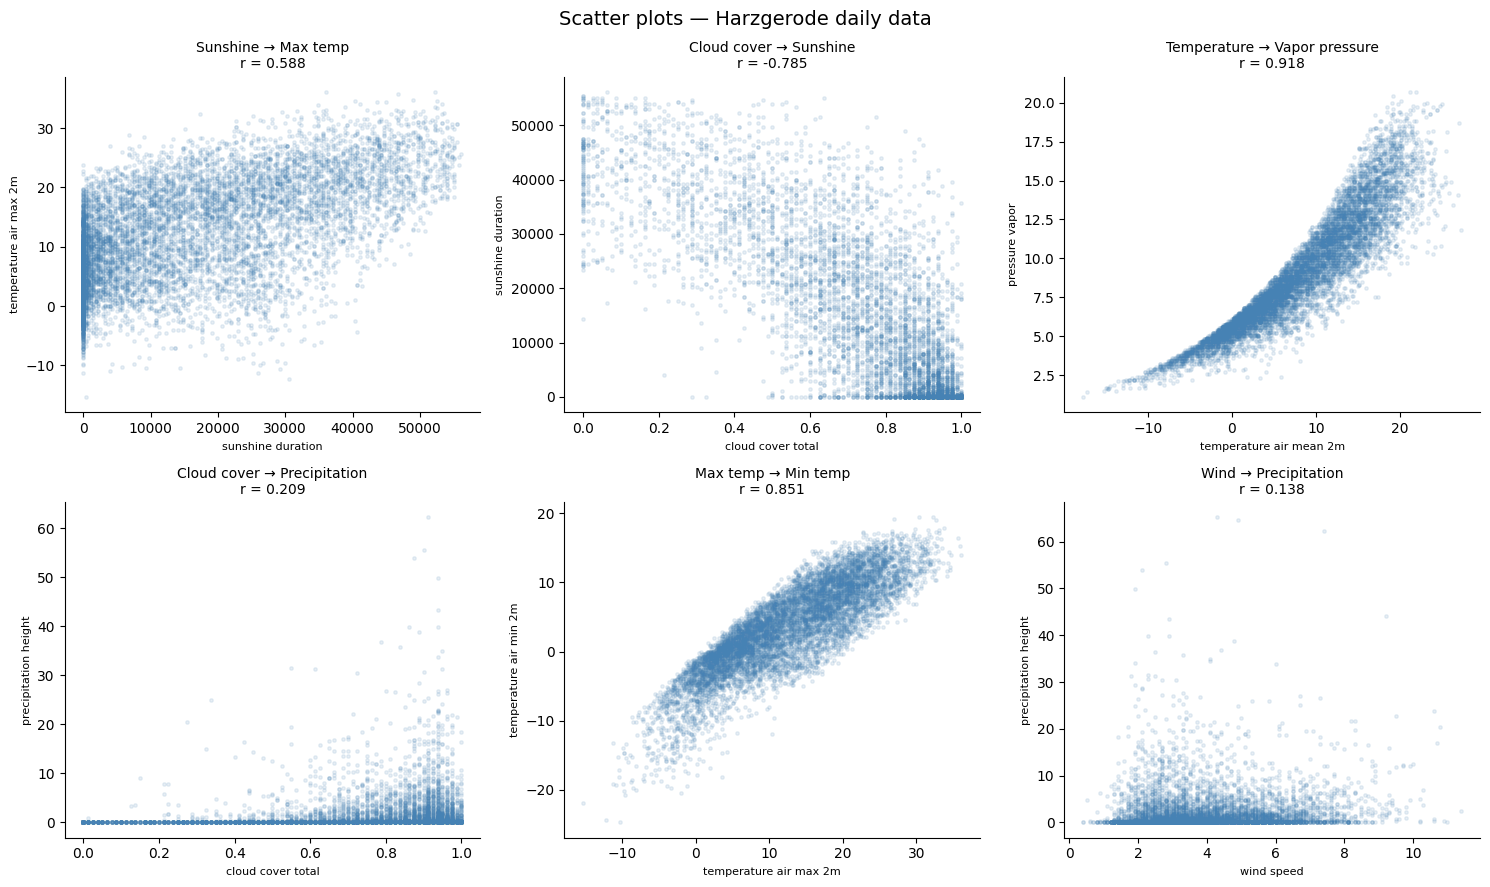

In [ ]:
# Scatter plots for key variable pairs

pairs = [
    ('sunshine_duration',       'temperature_air_max_2m', 'Sunshine → Max temp'),
    ('cloud_cover_total',       'sunshine_duration',      'Cloud cover → Sunshine'),
    ('temperature_air_mean_2m', 'pressure_vapor',         'Temperature → Vapor pressure'),
    ('cloud_cover_total',       'precipitation_height',   'Cloud cover → Precipitation'),
    ('temperature_air_max_2m',  'temperature_air_min_2m', 'Max temp → Min temp'),
    ('wind_speed',              'precipitation_height',   'Wind → Precipitation'),
]

# Keep only pairs where both variables exist
pairs = [(x, y, t) for x, y, t in pairs if x in df.columns and y in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Scatter plots — Harzgerode daily data', fontsize=14)

for ax, (xvar, yvar, title) in zip(axes.flat, pairs):
    sub = df[[xvar, yvar]].dropna()
    r   = sub[xvar].corr(sub[yvar])
    ax.scatter(sub[xvar], sub[yvar], alpha=0.12, s=6, color='steelblue')
    ax.set_xlabel(xvar.replace('_', ' '), fontsize=8)
    ax.set_ylabel(yvar.replace('_', ' '), fontsize=8)
    ax.set_title(f'{title}\nr = {r:.3f}', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


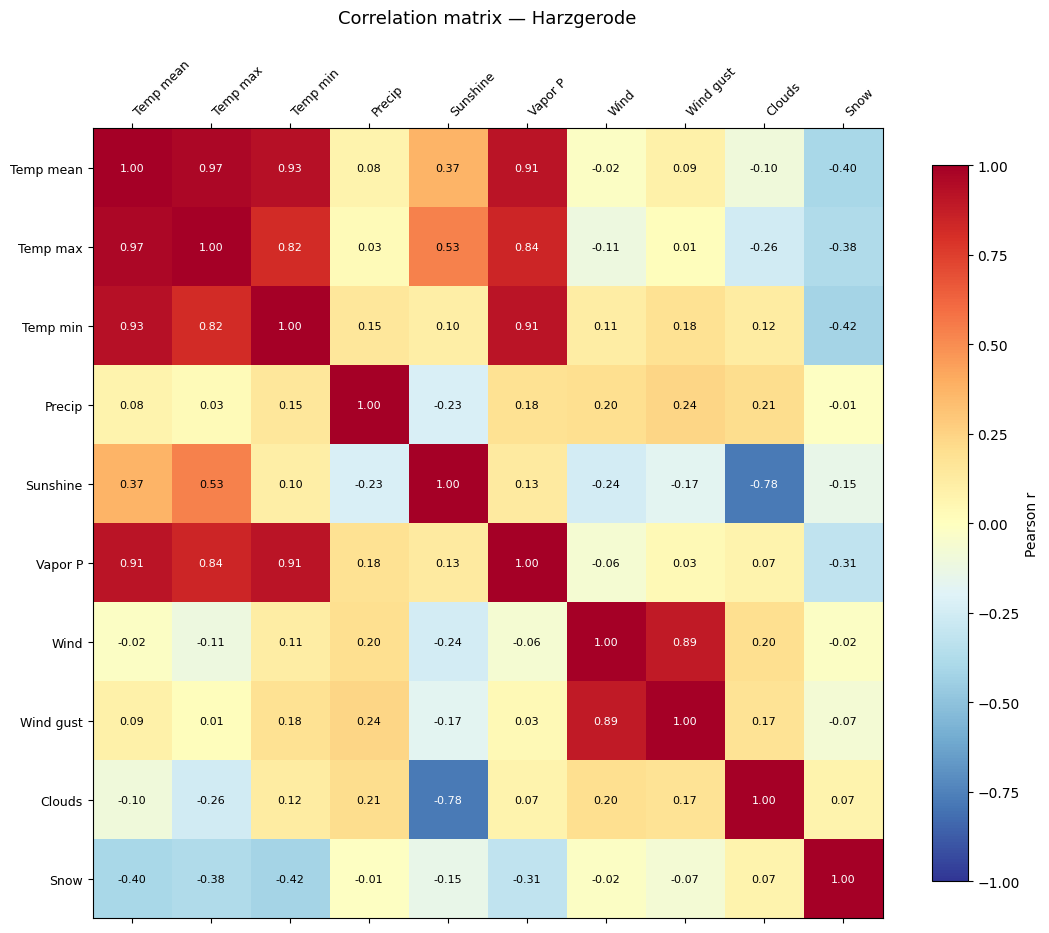

Strongest correlations:
  Temp mean       ↔ Temp max         r = +0.967
  Temp max        ↔ Temp mean        r = +0.967
  Temp mean       ↔ Temp min         r = +0.926
  Temp min        ↔ Temp mean        r = +0.926
  Temp mean       ↔ Vapor P          r = +0.908
  Vapor P         ↔ Temp mean        r = +0.908


In [ ]:
# Correlation matrix heatmap

corr_vars = [c for c in [
    'temperature_air_mean_2m',
    'temperature_air_max_2m',
    'temperature_air_min_2m',
    'precipitation_height',
    'sunshine_duration',
    'pressure_vapor',
    'wind_speed',
    'wind_gust_max',
    'cloud_cover_total',
    'snow_depth',
] if c in df.columns]

short = {
    'temperature_air_mean_2m': 'Temp mean',
    'temperature_air_max_2m':  'Temp max',
    'temperature_air_min_2m':  'Temp min',
    'precipitation_height':    'Precip',
    'sunshine_duration':       'Sunshine',
    'pressure_vapor':          'Vapor P',
    'wind_speed':              'Wind',
    'wind_gust_max':           'Wind gust',
    'cloud_cover_total':       'Clouds',
    'snow_depth':              'Snow',
}

corr_matrix = df[corr_vars].dropna().corr()
labels = [short.get(c, c) for c in corr_vars]
n      = len(labels)

fig, ax = plt.subplots(figsize=(11, 10))
mat = ax.matshow(corr_matrix.values, cmap='RdYlBu_r', vmin=-1, vmax=1)
plt.colorbar(mat, ax=ax, shrink=0.8, label='Pearson r')

ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha='left', fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)

for i in range(n):
    for j in range(n):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(val) > 0.6 else 'black')

ax.set_title('Correlation matrix — Harzgerode', fontsize=13, pad=25)
plt.tight_layout()
plt.show()

# Print strongest pairs
corr_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)
print('Strongest correlations:')
for (v1, v2), _ in corr_no_diag.abs().stack().sort_values(ascending=False).head(6).items():
    print(f'  {short.get(v1,v1):<15} ↔ {short.get(v2,v2):<15}  r = {corr_matrix.loc[v1,v2]:+.3f}')


In [ ]:
# TASK — does correlation change by season?

print('Correlation: sunshine duration vs max temperature')
print()
for season, months in [('Winter (DJF)', [12,1,2]), ('Summer (JJA)', [6,7,8])]:
    mask = df.index.month.isin(months)
    sub  = df[mask][['sunshine_duration','temperature_air_max_2m']].dropna()
    r    = sub['sunshine_duration'].corr(sub['temperature_air_max_2m'])
    print(f'  {season:<20}  r = {r:.3f}  (n = {len(sub):,} days)')

Correlation: sunshine duration vs max temperature

  Winter (DJF)          r = 0.084  (n = 2,160 days)
  Summer (JJA)          r = 0.599  (n = 2,202 days)


---
## Part 5 — Linear Regression: Step by Step

We found **sunshine duration** and **maximum temperature** are correlated.
Now we fit a line and use it to **predict** max temperature from sunshine.

$$y = a \cdot x + b$$

- $x$ = sunshine duration (predictor / input)
- $y$ = max temperature (target / output)
- $a$ = slope
- $b$ = intercept


In [ ]:
# Fit the model with scipy.stats.linregress

sub = df[['sunshine_duration', 'temperature_air_max_2m']].dropna()
x   = sub['sunshine_duration'].values
y   = sub['temperature_air_max_2m'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print('Linear regression: sunshine → max temperature')
print(f'  Slope      : {slope:.3f}  °C per hour of sunshine')
print(f'  Intercept  : {intercept:.2f}  °C (expected max temp with 0h sunshine)')
print(f'  R²         : {r_value**2:.3f}')
print(f'  p-value    : {p_value:.2e}')
print(f'  Std error  : {std_err:.4f}')
print()
print(f'Interpretation:')
print(f'  Each extra hour of sunshine adds {slope:.2f}°C to the maximum temperature.')
print(f'  The model explains {r_value**2*100:.0f}% of the variance in max temperature.')


Linear regression: sunshine → max temperature
  Slope      : 0.000  °C per hour of sunshine
  Intercept  : 7.00  °C (expected max temp with 0h sunshine)
  R²         : 0.346
  p-value    : 0.00e+00
  Std error  : 0.0000

Interpretation:
  Each extra hour of sunshine adds 0.00°C to the maximum temperature.
  The model explains 35% of the variance in max temperature.


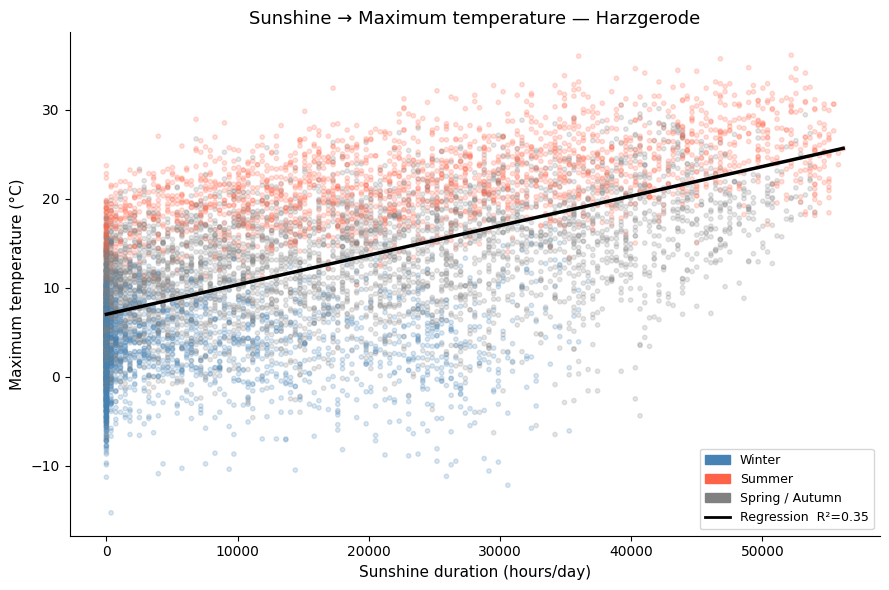

In [ ]:
# Scatter plot with regression line, coloured by season

x_line = np.linspace(0, x.max(), 200)
y_line = slope * x_line + intercept

months = sub.index.month
point_colors = ['steelblue' if m in [12,1,2] else
                'tomato'    if m in [6,7,8]  else
                'grey' for m in months]

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x, y, c=point_colors, alpha=0.2, s=10)
ax.plot(x_line, y_line, color='black', linewidth=2.5,
        label=f'y = {slope:.2f}x + {intercept:.1f}   R²={r_value**2:.2f}')
ax.legend(handles=[
    Patch(color='steelblue', label='Winter'),
    Patch(color='tomato',    label='Summer'),
    Patch(color='grey',      label='Spring / Autumn'),
    plt.Line2D([0],[0], color='black', linewidth=2,
               label=f'Regression  R²={r_value**2:.2f}'),
], fontsize=9)
ax.set_xlabel('Sunshine duration (hours/day)', fontsize=11)
ax.set_ylabel('Maximum temperature (°C)', fontsize=11)
ax.set_title('Sunshine → Maximum temperature — Harzgerode', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# What does R² actually mean? Manual calculation.

y_pred    = slope * x + intercept
ss_total  = np.sum((y - y.mean())**2)
ss_resid  = np.sum((y - y_pred)**2)
r2_manual = 1 - ss_resid / ss_total

print('R² from scratch:')
print(f'  Total variance in y        : {ss_total:.0f}')
print(f'  Variance explained by model: {ss_total - ss_resid:.0f}')
print(f'  Variance not explained     : {ss_resid:.0f}')
print()
print(f'  R² = 1 - {ss_resid:.0f} / {ss_total:.0f} = {r2_manual:.3f}')
print(f'  Matches scipy: {r_value**2:.3f}')
print()
print(f'  {r2_manual*100:.0f}% of max temperature variation is explained by sunshine.')
print(f'  {(1-r2_manual)*100:.0f}% comes from other factors: season, humidity, fronts...')

R² from scratch:
  Total variance in y        : 652737
  Variance explained by model: 225804
  Variance not explained     : 426933

  R² = 1 - 426933 / 652737 = 0.346
  Matches scipy: 0.346

  35% of max temperature variation is explained by sunshine.
  65% comes from other factors: season, humidity, fronts...


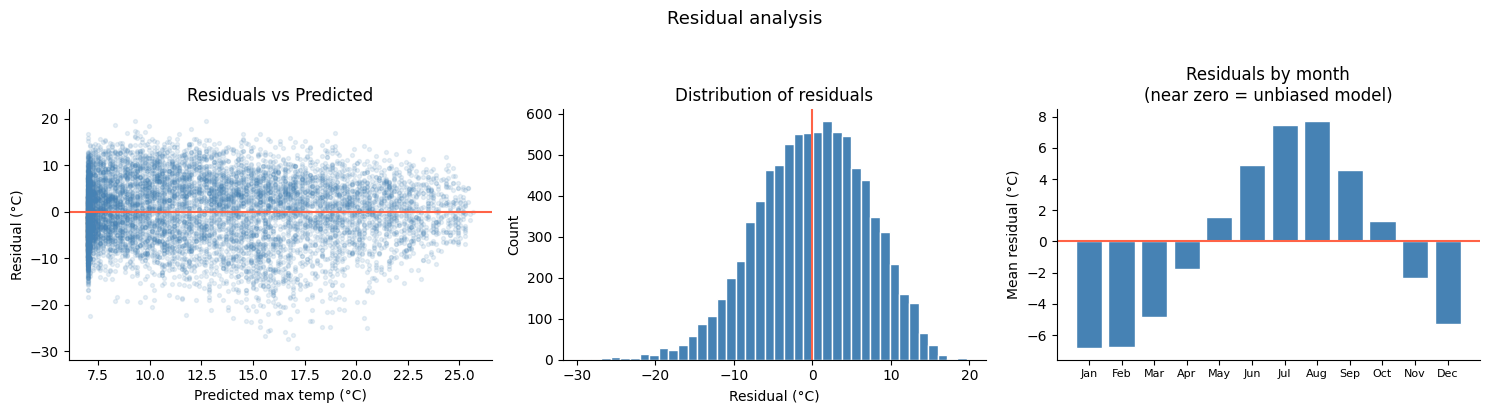

Mean residual : -0.000 °C  (should be ~0)
Std residual  : 7.00 °C  (typical error per day)


In [ ]:
# Residuals analysis

residuals  = y - y_pred
res_series = pd.Series(residuals, index=sub.index)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred, residuals, alpha=0.12, s=8, color='steelblue')
axes[0].axhline(0, color='tomato', linewidth=1.5)
axes[0].set_xlabel('Predicted max temp (°C)')
axes[0].set_ylabel('Residual (°C)')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='tomato', linewidth=1.5)
axes[1].set_xlabel('Residual (°C)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of residuals')

monthly_res = res_series.groupby(res_series.index.month).mean()
axes[2].bar(range(1,13), monthly_res.values, color='steelblue', edgecolor='white')
axes[2].axhline(0, color='tomato', linewidth=1.5)
axes[2].set_xticks(range(1,13))
axes[2].set_xticklabels(MONTH_NAMES, fontsize=8)
axes[2].set_ylabel('Mean residual (°C)')
axes[2].set_title('Residuals by month\n(near zero = unbiased model)')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Residual analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean residual : {residuals.mean():.3f} °C  (should be ~0)')
print(f'Std residual  : {residuals.std():.2f} °C  (typical error per day)')


Season        Slope  Intercept       R²       N
-----------------------------------------------
Winter        0.000       2.79    0.007    2160
Spring        0.000       7.81    0.281    2204
Summer        0.000      17.66    0.359    2202
Autumn        0.000       8.94    0.319    2150


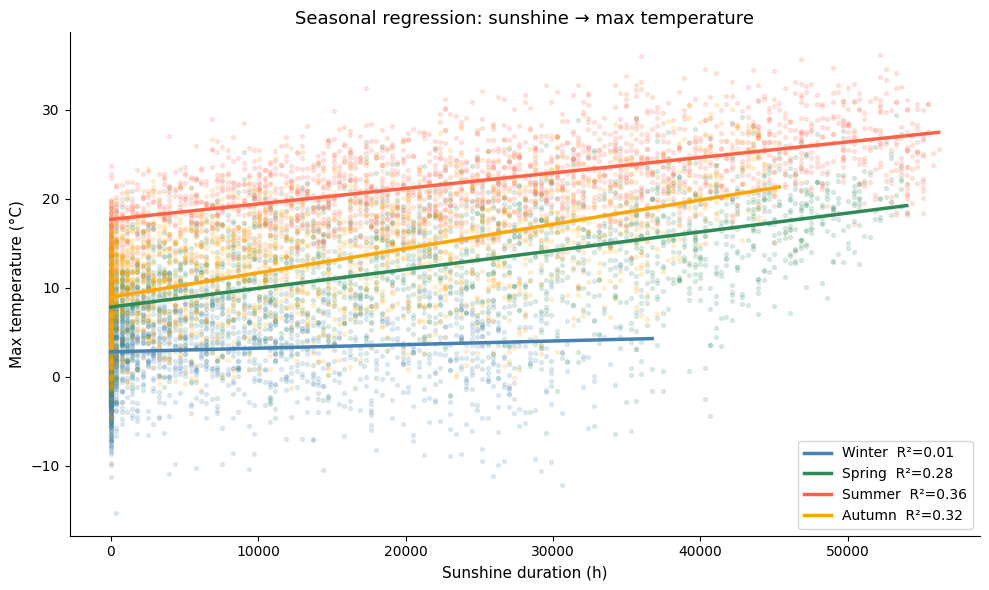

In [ ]:
# TASK — seasonal regression lines
# Does splitting by season improve R²?

seasons_def = {
    'Winter': ([12,1,2],   'steelblue'),
    'Spring': ([3,4,5],    'seagreen'),
    'Summer': ([6,7,8],    'tomato'),
    'Autumn': ([9,10,11],  'orange'),
}

fig, ax = plt.subplots(figsize=(10, 6))
print(f'{"Season":<10} {"Slope":>8} {"Intercept":>10} {"R²":>8} {"N":>7}')
print('-' * 47)

for season, (months, color) in seasons_def.items():
    mask = sub.index.month.isin(months)
    s    = sub[mask]
    if len(s) < 30:
        continue
    xs = s['sunshine_duration'].values
    ys = s['temperature_air_max_2m'].values
    sl, ic, rv, _, _ = stats.linregress(xs, ys)
    x_l = np.linspace(xs.min(), xs.max(), 100)
    ax.scatter(xs, ys, alpha=0.15, s=8, color=color)
    ax.plot(x_l, sl*x_l+ic, color=color, linewidth=2.5,
            label=f'{season}  R²={rv**2:.2f}')
    print(f'{season:<10} {sl:>8.3f} {ic:>10.2f} {rv**2:>8.3f} {len(s):>7}')

ax.set_xlabel('Sunshine duration (h)', fontsize=11)
ax.set_ylabel('Max temperature (°C)', fontsize=11)
ax.set_title('Seasonal regression: sunshine → max temperature', fontsize=13)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


---
## Part 6 — Predicting Tomorrow's Temperature

So far we predicted max temperature from sunshine on the **same day**.
That is not forecasting — we need tomorrow's sunshine in advance!

A real forecast uses **today's measurements** to predict **tomorrow**.


In [ ]:
# Persistence model: today's temp predicts tomorrow's temp

temp = df['temperature_air_mean_2m'].dropna()

forecast_df = pd.DataFrame({
    'today':    temp,
    'tomorrow': temp.shift(-1)
}).dropna()

sl, ic, rv, pv, _ = stats.linregress(
    forecast_df['today'].values,
    forecast_df['tomorrow'].values
)
y_pers = sl * forecast_df['today'].values + ic
rmse   = np.sqrt(np.mean((forecast_df['tomorrow'].values - y_pers)**2))

print('Persistence model: today → tomorrow')
print(f'  R²   : {rv**2:.3f}')
print(f'  RMSE : {rmse:.2f} °C')
print()
print(f'Just knowing today\'s temperature explains {rv**2*100:.0f}% of tomorrow\'s variance.')


Persistence model: today → tomorrow
  R²   : 0.901
  RMSE : 2.29 °C

Just knowing today's temperature explains 90% of tomorrow's variance.


In [ ]:
# TASK

forecast_df2 = pd.DataFrame({
    'today_temp':    df['temperature_air_mean_2m'],
    'today_cloud':   df['cloud_cover_total'],
    'today_sun':     df['sunshine_duration'],
    'tomorrow_temp': df['temperature_air_mean_2m'].shift(-1)
}).dropna()

y_true = forecast_df2['tomorrow_temp'].values

features = {
    'Temp only':          ['today_temp'],
    'Temp + Cloud':       ['today_temp', 'today_cloud'],
    'Temp + Sunshine':    ['today_temp', 'today_sun'],
    'Temp + Cloud + Sun': ['today_temp', 'today_cloud', 'today_sun'],
}

print(f'{"Features":<25} {"R²":>8} {"RMSE (°C)":>10}')
print('-' * 47)

for name, feat_cols in features.items():
    X = np.column_stack([forecast_df2[c].values for c in feat_cols] +
                        [np.ones(len(forecast_df2))])
    coeffs, _, _, _ = np.linalg.lstsq(X, y_true, rcond=None)
    y_pred_f = X @ coeffs
    r2   = 1 - np.sum((y_true - y_pred_f)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred_f)**2))
    print(f'{name:<25} {r2:>8.3f} {rmse:>10.2f}')

print()
print('💬 Adding features helps slightly.')
print('   Temperature is very autocorrelated — tomorrow is usually close to today.')


Features                        R²  RMSE (°C)
-----------------------------------------------
Temp only                    0.901       2.31
Temp + Cloud                 0.903       2.29
Temp + Sunshine              0.904       2.27
Temp + Cloud + Sun           0.904       2.27

💬 Adding features helps slightly.
   Temperature is very autocorrelated — tomorrow is usually close to today.


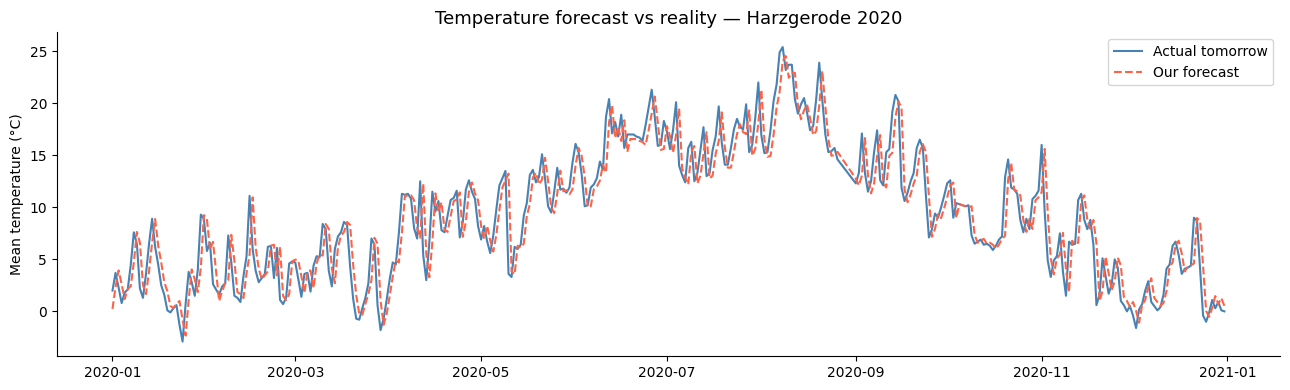

Forecast RMSE for 2020: 2.32 °C


In [ ]:
# Visualise forecast vs reality for one year

year_fc = forecast_df2[forecast_df2.index.year == 2020].copy()
X_year  = np.column_stack([year_fc['today_temp'].values,
                            np.ones(len(year_fc))])
coeffs, _, _, _ = np.linalg.lstsq(
    np.column_stack([forecast_df2['today_temp'].values,
                     np.ones(len(forecast_df2))]),
    y_true, rcond=None)
year_fc['predicted'] = X_year @ coeffs

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(year_fc.index, year_fc['tomorrow_temp'],
        color='steelblue', linewidth=1.5, label='Actual tomorrow')
ax.plot(year_fc.index, year_fc['predicted'],
        color='tomato', linewidth=1.5, linestyle='--', label='Our forecast')
ax.set_title('Temperature forecast vs reality — Harzgerode 2020', fontsize=13)
ax.set_ylabel('Mean temperature (°C)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

rmse_yr = np.sqrt(np.mean((year_fc['tomorrow_temp'] - year_fc['predicted'])**2))
print(f'Forecast RMSE for 2020: {rmse_yr:.2f} °C')


---
## Part 7 — Mini-Project: Station Explorer

Choose **any station in Germany**.

1. Fetch its `climate_summary` data for 2000–2023
2. Plot the correlation matrix
3. Find the two most correlated variables
4. Fit a linear regression for that pair
5. Check seasonality
6. One sentence summary of your finding